# Treinamento EfficientNet-B0 — C-NMC 2019

Classificação binária de imagens celulares:

- 0: normal;
- 1: maligna — LLA-B.

Divisão por pacientes:

- treino: folds 0 e 1;
- validação: fold 2;
- teste final: conjunto preliminar.

O conjunto de teste não será utilizado durante o treinamento.

In [1]:
!pip install -q kagglehub scikit-learn seaborn

In [3]:
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as error:
    print("Determinismo parcial:", error)

gpus = tf.config.list_physical_devices("GPU")

print("TensorFlow:", tf.__version__)
print("GPUs encontradas:", gpus)

assert gpus, (
    "Nenhuma GPU encontrada. "
    "Ative a GPU T4 nas configurações do Colab."
)

TensorFlow: 2.20.0
GPUs encontradas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/IT_2026"
)

METADATA_DIR = DRIVE_ROOT / "datasets" / "cnmc"

EXPERIMENT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "efficientnet_b0_cnmc"
)

CHECKPOINT_DIR = EXPERIMENT_DIR / "checkpoints"
FIGURES_DIR = EXPERIMENT_DIR / "figures"
LOGS_DIR = EXPERIMENT_DIR / "logs"

for directory in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    FIGURES_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "image_size": [224, 224],
    "batch_size": 32,
    "classes": {
        "0": "normal",
        "1": "malignant",
    },
    "backbone": "EfficientNetB0",
    "pretrained_weights": "imagenet",
    "initial_learning_rate": 1e-3,
    "initial_epochs": 15,
    "train_source": ["fold_0", "fold_1"],
    "validation_source": ["fold_2"],
    "test_source": "preliminary_test",
}

with (EXPERIMENT_DIR / "training_config.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Experimento:", EXPERIMENT_DIR)

Mounted at /content/drive
Experimento: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc


In [20]:
import kagglehub
from pathlib import Path


DATA_DIR = Path("/content/cnmc")

download_path = kagglehub.dataset_download(
    "shafiullahshafin/c-nmc-2019-dataset",
    output_dir=str(DATA_DIR),
)

package_directories = [
    path
    for path in DATA_DIR.rglob("C-NMC 2019 (PKG)")
    if path.is_dir()
    and (
        path / "C-NMC_training_data"
    ).is_dir()
]

assert package_directories, (
    "A pasta 'C-NMC 2019 (PKG)' não foi encontrada."
)

PACKAGE_DIR = package_directories[0]

# The 'relative_path' in the CSVs (e.g., 'C-NMC_training_data/...')
# is relative to the 'C-NMC 2019 (PKG)' folder.
# Therefore, the DATASET_ROOT should be PACKAGE_DIR itself.
DATASET_ROOT = PACKAGE_DIR

print("Retorno do KaggleHub:", download_path)
print("Pasta do pacote:", PACKAGE_DIR)
print("Raiz utilizada:", DATASET_ROOT)
print(
    "Imagens BMP:",
    len(list(PACKAGE_DIR.rglob("*.bmp"))),
)

Using Colab cache for faster access to the 'c-nmc-2019-dataset' dataset.
Retorno do KaggleHub: /kaggle/input/c-nmc-2019-dataset
Pasta do pacote: /content/cnmc/C-NMC 2019 (PKG)
Raiz utilizada: /content/cnmc/C-NMC 2019 (PKG)
Imagens BMP: 15114


In [23]:
LABEL_MAP = {
    "normal": 0,
    "malignant": 1,
}

SPLIT_FILES = {
    "train": METADATA_DIR / "cnmc_train.csv",
    "validation": METADATA_DIR / "cnmc_validation.csv",
    "test": METADATA_DIR / "cnmc_test.csv",
}


def load_split(split_name):
    csv_path = SPLIT_FILES[split_name]

    assert csv_path.exists(), (
        f"CSV não encontrado: {csv_path}"
    )

    dataframe = pd.read_csv(csv_path)

    dataframe["relative_path"] = (
        dataframe["relative_path"]
        .astype(str)
        .str.replace("\\", "/", regex=False)
    )

    # Re-evaluate image_path using the correctly set DATASET_ROOT
    dataframe["image_path"] = dataframe[
        "relative_path"
    ].apply(
        lambda path: str(DATASET_ROOT / path)
    )

    dataframe["label"] = dataframe[
        "class_name"
    ].map(LABEL_MAP)

    assert dataframe["label"].notna().all(), (
        f"Classe desconhecida no conjunto {split_name}"
    )

    dataframe["label"] = dataframe[
        "label"
    ].astype("int32")

    return dataframe


train_df = load_split("train")
validation_df = load_split("validation")
test_df = load_split("test")

print("Treino:", len(train_df))
print("Validação:", len(validation_df))
print("Teste:", len(test_df))

Treino: 7108
Validação: 3553
Teste: 1867


In [22]:
splits = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for split_name, dataframe in splits.items():
    missing_files = dataframe[
        "image_path"
    ].apply(
        lambda path: not Path(path).is_file()
    )

    print(
        split_name,
        "| imagens:",
        len(dataframe),
        "| pacientes:",
        dataframe["subject_id"].nunique(),
        "| ausentes:",
        int(missing_files.sum()),
    )

    assert not missing_files.any(), (
        f"Existem imagens ausentes em {split_name}"
    )

train_subjects = set(train_df["subject_id"])
validation_subjects = set(validation_df["subject_id"])
test_subjects = set(test_df["subject_id"])

assert train_subjects.isdisjoint(validation_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert validation_subjects.isdisjoint(test_subjects)

print(
    "Divisão aprovada: nenhum paciente compartilhado."
)

train | imagens: 7108 | pacientes: 42 | ausentes: 0
validation | imagens: 3553 | pacientes: 31 | ausentes: 0
test | imagens: 1867 | pacientes: 28 | ausentes: 0
Divisão aprovada: nenhum paciente compartilhado.


In [24]:
distribution = pd.concat(
    [
        dataframe.assign(split=split_name)
        for split_name, dataframe in splits.items()
    ],
    ignore_index=True,
)

summary = (
    distribution
    .groupby(["split", "class_name"])
    .agg(
        images=("relative_path", "count"),
        subjects=("subject_id", "nunique"),
    )
    .reset_index()
)

display(summary)

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy(),
)

CLASS_WEIGHT = {
    int(label): float(weight)
    for label, weight in zip(classes, weights)
}

print("Pesos das classes:", CLASS_WEIGHT)

,split,class_name,images,subjects
0,test,malignant,1219,13
1,test,normal,648,15
2,train,malignant,4815,30
3,train,normal,2293,12
4,validation,malignant,2457,17
5,validation,normal,1096,14


Pesos das classes: {0: 1.5499345835150458, 1: 0.7381100726895119}


In [25]:
IMAGE_SIZE = tuple(CONFIG["image_size"])
BATCH_SIZE = CONFIG["batch_size"]
AUTOTUNE = tf.data.AUTOTUNE


def decode_and_resize(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_bmp(
        image_bytes,
        channels=3,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        antialias=True,
    )

    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe[
        "image_path"
    ].astype(str).to_numpy()

    labels = dataframe[
        "label"
    ].to_numpy(dtype=np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        decode_and_resize,
        num_parallel_calls=AUTOTUNE,
        deterministic=True,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = make_dataset(
    train_df,
    training=True,
)

validation_dataset = make_dataset(
    validation_df,
)

test_dataset = make_dataset(
    test_df,
)

In [26]:
images, labels = next(iter(train_dataset))

print("Formato das imagens:", images.shape)
print("Formato dos rótulos:", labels.shape)
print("Pixel mínimo:", float(tf.reduce_min(images)))
print("Pixel máximo:", float(tf.reduce_max(images)))
print("Rótulos:", np.unique(labels.numpy()))

assert images.shape[1:] == (224, 224, 3)
assert float(tf.reduce_min(images)) >= 0
assert float(tf.reduce_max(images)) <= 255
assert set(np.unique(labels.numpy())).issubset(
    {0.0, 1.0}
)

Formato das imagens: (32, 224, 224, 3)
Formato dos rótulos: (32,)
Pixel mínimo: 0.0
Pixel máximo: 144.4779815673828
Rótulos: [0. 1.]


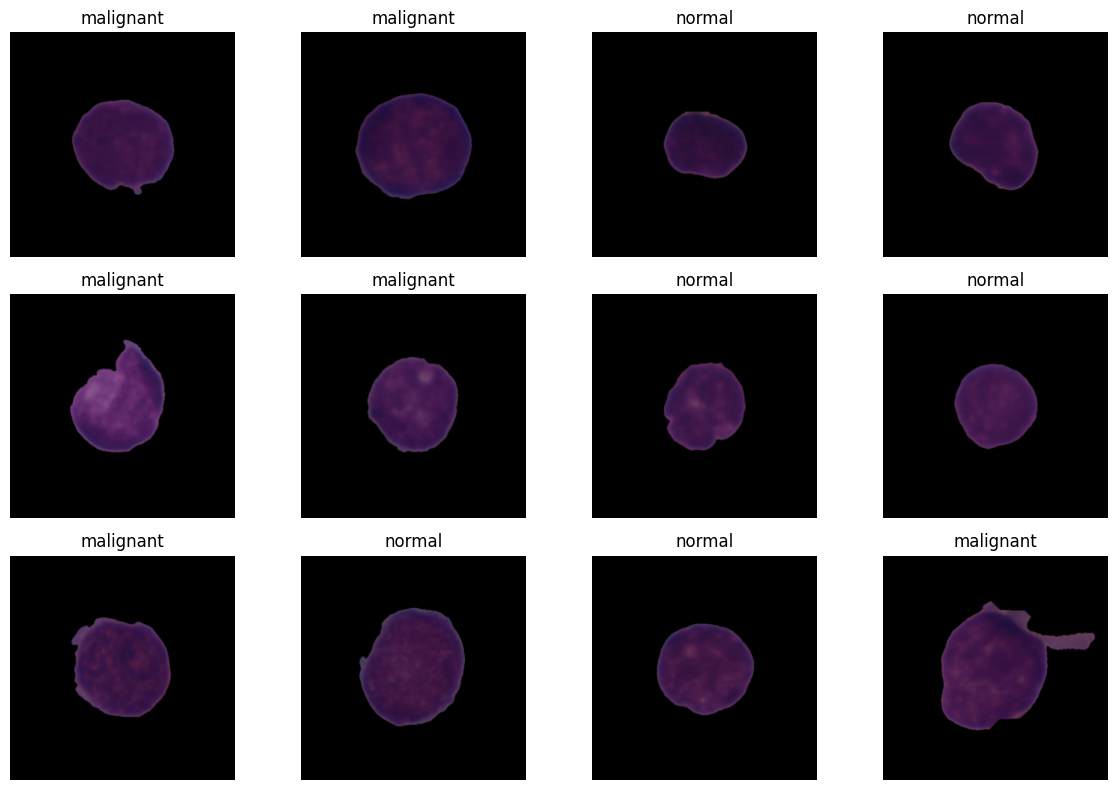

In [27]:
CLASS_NAMES = {
    0: "normal",
    1: "malignant",
}

plt.figure(figsize=(12, 8))

for index in range(12):
    plt.subplot(3, 4, index + 1)
    plt.imshow(
        tf.cast(images[index], tf.uint8)
    )

    label = int(labels[index].numpy())

    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Augmentation

In [28]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal_and_vertical",
            seed=SEED,
        ),
        tf.keras.layers.RandomRotation(
            factor=0.05,
            seed=SEED,
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED,
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=SEED,
        ),
    ],
    name="data_augmentation",
)

# EfficientNet-B0

In [29]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="image",
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False,
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)

x = tf.keras.layers.Dropout(
    rate=0.30,
    name="dropout",
)(x)

outputs = tf.keras.layers.Dense(
    units=1,
    activation="sigmoid",
    dtype="float32",
    name="malignant_probability",
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="efficientnet_b0_cnmc",
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnet_b0_cnmc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malignant_probability (Dense)   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CONFIG[
            "initial_learning_rate"
        ],
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.Precision(
            name="precision",
        ),
        tf.keras.metrics.Recall(
            name="recall",
        ),
        tf.keras.metrics.AUC(
            name="auc",
        ),
    ],
)

trainable_parameters = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_parameters = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(
    "Parâmetros treináveis:",
    f"{trainable_parameters:,}",
)

print(
    "Parâmetros congelados:",
    f"{non_trainable_parameters:,}",
)

print(
    "Backbone treinável:",
    base_model.trainable,
)

Parâmetros treináveis: 1,281
Parâmetros congelados: 4,049,571.0
Backbone treinável: False


In [31]:
FROZEN_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_frozen.keras"
)

FROZEN_HISTORY_PATH = (
    LOGS_DIR
    / "frozen_training_history.csv"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FROZEN_MODEL_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(FROZEN_HISTORY_PATH),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

print("Checkpoint:", FROZEN_MODEL_PATH)
print("Histórico:", FROZEN_HISTORY_PATH)

Checkpoint: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras
Histórico: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/logs/frozen_training_history.csv


In [32]:
history_frozen = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CONFIG["initial_epochs"],
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7017 - auc: 0.7521 - loss: 0.5738 - precision: 0.8200 - recall: 0.7258
Epoch 1: val_auc improved from None to 0.74462, saving model to /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 82s 287ms/step - accuracy: 0.7442 - auc: 0.8134 - loss: 0.5292 - precision: 0.8500 - recall: 0.7558 - val_accuracy: 0.7287 - val_auc: 0.7446 - val_loss: 0.5502 - val_precision: 0.7973 - val_recall: 0.8148 - learning_rate: 0.0010
Epoch 2/15
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7824 - auc: 0.8511 - loss: 0.4830 - precision: 0.8720 - recall: 0.7916
Epoch 2: val_auc improved from 0.74462 to 0.76381, saving model to /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras

Epoch 2: finish

In [33]:
history_data = {
    metric: [
        float(value)
        for value in values
    ]
    for metric, values
    in history_frozen.history.items()
}

with (
    LOGS_DIR
    / "frozen_training_history.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        history_data,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Histórico salvo.")

Histórico salvo.


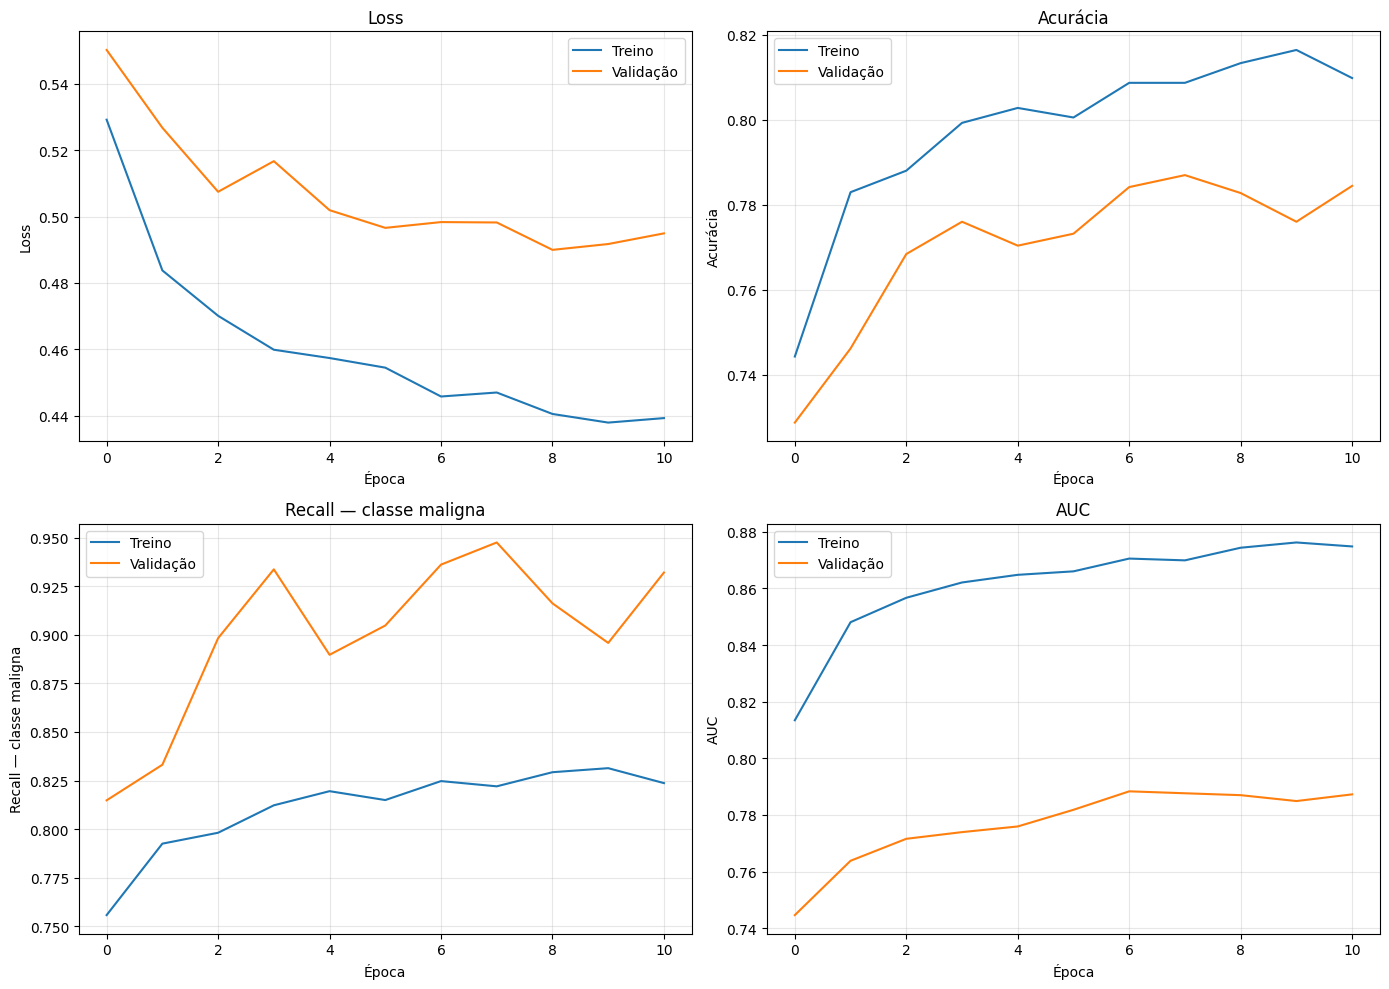

Figura salva em: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/figures/frozen_training_curves.png


In [34]:
metrics_to_plot = [
    ("loss", "Loss"),
    ("accuracy", "Acurácia"),
    ("recall", "Recall — classe maligna"),
    ("auc", "AUC"),
]

plt.figure(figsize=(14, 10))

for index, (metric, title) in enumerate(
    metrics_to_plot,
    start=1,
):
    plt.subplot(2, 2, index)

    plt.plot(
        history_frozen.history[metric],
        label="Treino",
    )

    plt.plot(
        history_frozen.history[f"val_{metric}"],
        label="Validação",
    )

    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(title)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "frozen_training_curves.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figura salva em:", figure_path)

In [35]:
best_frozen_model = tf.keras.models.load_model(
    FROZEN_MODEL_PATH
)

validation_metrics = best_frozen_model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1,
)

validation_metrics = {
    metric: float(value)
    for metric, value
    in validation_metrics.items()
}

print("Métricas de validação:")

for metric, value in validation_metrics.items():
    print(f"{metric}: {value:.4f}")

with (
    LOGS_DIR
    / "frozen_validation_metrics.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        validation_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )

112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.7841 - auc: 0.7883 - loss: 0.4983 - precision: 0.7904 - recall: 0.9361
Métricas de validação:
accuracy: 0.7841
auc: 0.7883
loss: 0.4983
precision: 0.7904
recall: 0.9361


## Resultado do treinamento inicial

O treinamento inicial foi realizado com o backbone da EfficientNet-B0
congelado e pesos pré-treinados na ImageNet. O treinamento foi interrompido
automaticamente após 11 épocas, tendo o melhor checkpoint sido obtido na
época 7.

### Métricas de validação

- Acurácia: 0,7841
- AUC: 0,7883
- Loss: 0,4983
- Precisão: 0,7904
- Recall: 0,9361

As curvas indicam um afastamento moderado entre treinamento e validação a
partir aproximadamente da sétima época. Entretanto, o uso de early stopping
e checkpoint preservou a configuração com maior AUC de validação.

O recall elevado indica boa sensibilidade para a classe maligna, enquanto a
diferença entre recall e precisão sugere a ocorrência de falsos positivos.
Esses resultados serão analisados posteriormente por meio da matriz de
confusão e do ajuste do limiar de classificação.